In [1]:
import math
import random

class value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other= other if isinstance(other, value) else value(other)
        out = value(self.data + other.data, (self, other), '+')
        
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, value) else value(other)
        out = value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = value(self.data**other, (self, ), f'**{other}')

        def _backward():
            self.grad += other * self.data**(other - 1) * out.grad
        out._backward = _backward

        return out

    def __rmul__(self, other):
        return self * other

    def __radd__(self, other):
        return self + other

    def __truediv__(self, other):
        return self * other**-1

    def __neg__(self):
        return self * -1

    def __sub__(self, other):
        return self + (-other)

    def exp(self):
        x = self.data
        out = value(math.exp(x), (self, ), 'exp')

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward

        return out

    def tanh(self):
        x = self.data
        t = math.tanh(x) 
        out = value(t, (self, ), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward

        return out

    def backward(self):
        topo = []
        visited = set()

        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()


In [2]:
class Neuron:

    def __init__(self, nin):
        self.w = [value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = value(random.uniform(-1, 1))

    def __call__(self, x):
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]

class Layer:

    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:

    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i + 1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]


In [3]:
x = [2, 3, -1]
n = MLP(3, [4, 4, 1])
n(x)

Value(data=0.14389073575471062)

In [4]:
xs = [
    [2, 3, -1],
    [3, -1, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]
ys = [1, -1, -1, 1]

In [5]:
for k in range(20):
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

    for p in n.parameters():
        p.grad = 0.0
    loss.backward()

    for p in n.parameters():
        p.data += -0.05 * p.grad    

    print ('loss',k, loss.data)

loss 0 4.144764759146771
loss 1 3.0759831190468137
loss 2 2.2650966650231994
loss 3 1.488023910836418
loss 4 0.9440682100037853
loss 5 0.6265070991391869
loss 6 0.4422170484092519
loss 7 0.3297172017691789
loss 8 0.2569789321653218
loss 9 0.20742618545061348
loss 10 0.17212810683747884
loss 11 0.14602858337944832
loss 12 0.1261216779970637
loss 13 0.11053851626147748
loss 14 0.09807009310272541
loss 15 0.08790656531546295
loss 16 0.07948869245557885
loss 17 0.07241985248954996
loss 18 0.06641208505114626
loss 19 0.06125195084833321


In [6]:
ypred

[Value(data=0.8932927699839719),
 Value(data=-0.9239013652076058),
 Value(data=-0.8301108592074404),
 Value(data=0.8766622704354448)]

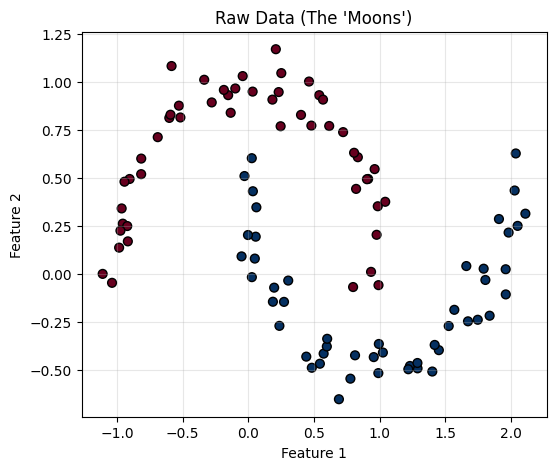

Training...
Step 0, Loss 129.2656
Step 20, Loss 15.4600
Step 40, Loss 0.5056
Step 60, Loss 0.2621
Step 80, Loss 0.2032
Step 100, Loss 0.1659
Step 120, Loss 0.1398
Step 140, Loss 0.1206
Step 160, Loss 0.1058
Step 180, Loss 0.0941
Visualizing...


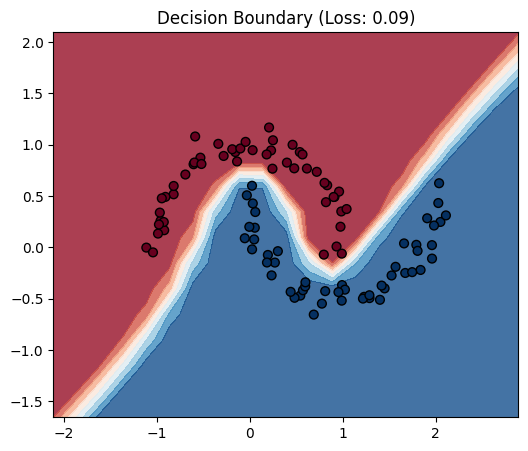

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=100, noise=0.1)
y = y * 2 - 1

plt.figure(figsize=(6, 5))
plt.scatter(X[:,0], X[:,1], c=y, s=40, cmap='RdBu', edgecolors='k')
plt.title("Raw Data (The 'Moons')")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True, alpha=0.3)
plt.show()

n = MLP(2, [16, 16, 1])

print("Training...")
learning_rate = -0.01 

for k in range(200):
    ypred = [n(x) for x in X]
    loss = sum((yout - ygt)**2 for ygt, yout in zip(y, ypred))
    
    for p in n.parameters():
        p.grad = 0.0
    
    loss.backward()
    
    for p in n.parameters():
        p.data += learning_rate * p.grad
        
    if k % 20 == 0:
        print(f"Step {k}, Loss {loss.data:.4f}")

print("Visualizing...")
h = 0.25
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

Z = []
for x_in in zip(xx.ravel(), yy.ravel()):
    Z.append(n(list(x_in)).data)

Z = np.array(Z).reshape(xx.shape)

plt.figure(figsize=(6,5))
plt.contourf(xx, yy, Z, cmap='RdBu', alpha=0.8)
plt.scatter(X[:,0], X[:,1], c=y, s=40, edgecolors='k', cmap='RdBu')
plt.title(f"Decision Boundary (Loss: {loss.data:.2f})")
plt.show()

Training...
Step 0, Loss 41.1086
Step 10, Loss 0.0221
Step 20, Loss 0.0133
Step 30, Loss 0.0105
Step 40, Loss 0.0089
Step 50, Loss 0.0077
Step 60, Loss 0.0069
Step 70, Loss 0.0062


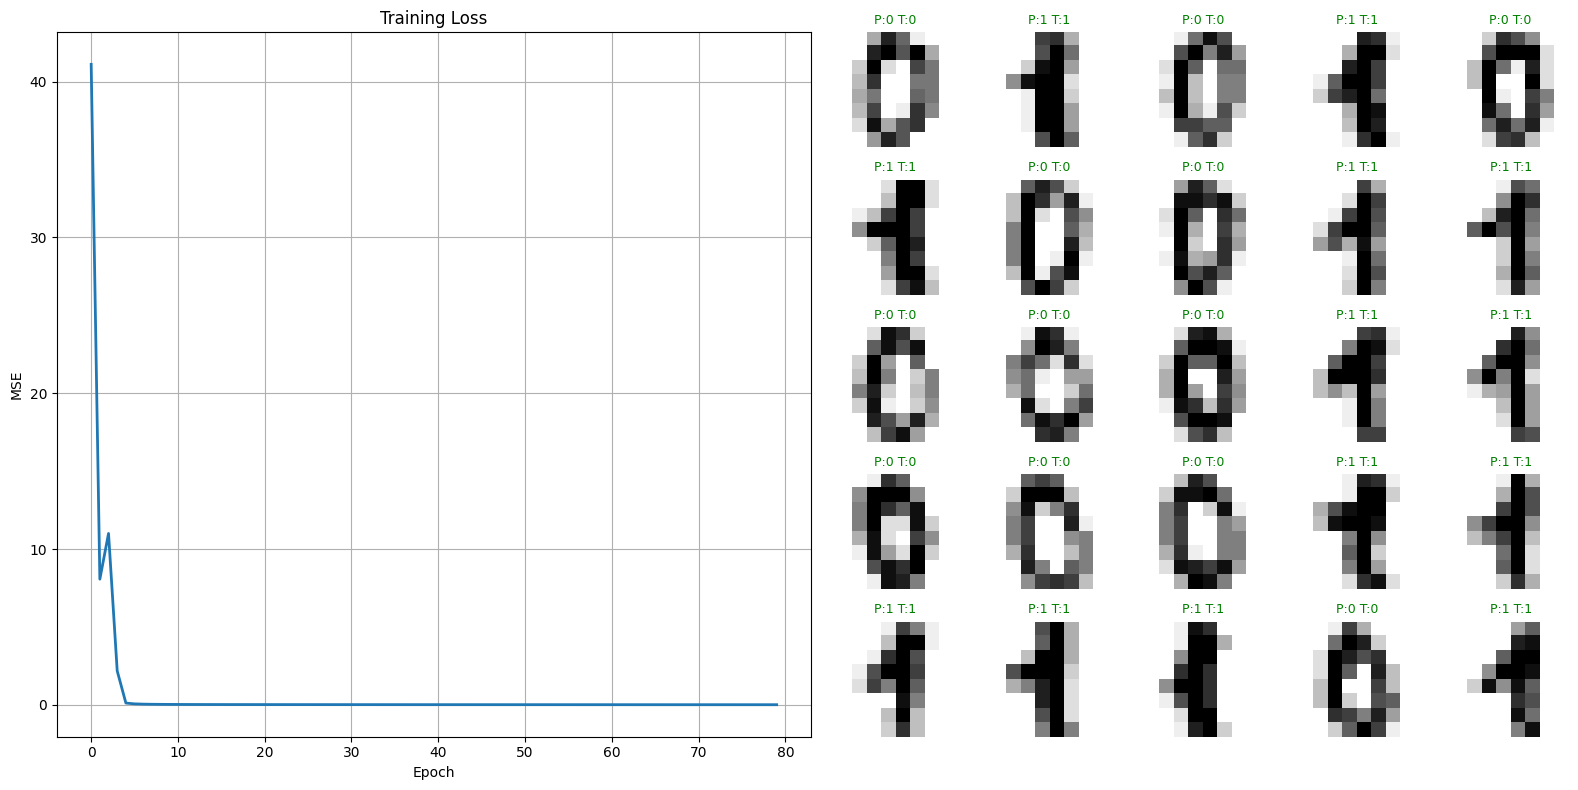

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_digits
import matplotlib.gridspec as gridspec

digits = load_digits()
indices = (digits.target == 0) | (digits.target == 1)
X_raw = digits.data[indices]
y_raw = digits.target[indices]

X = X_raw / 16.0
y = y_raw * 2 - 1

n = MLP(64, [16, 1])

print("Training...")
subset_size = 25
X_subset = X[:subset_size]
y_subset = y[:subset_size]

losses = []
lr = 0.02

for k in range(80):
    ypred = [n(x) for x in X_subset]
    loss = sum((yout - ygt) ** 2 for ygt, yout in zip(y_subset, ypred))
    losses.append(loss.data)

    for p in n.parameters():
        p.grad = 0.0

    loss.backward()

    for p in n.parameters():
        p.data += -lr * p.grad

    if k % 10 == 0:
        print(f"Step {k}, Loss {loss.data:.4f}")

plt.figure(figsize=(16, 8))
gs = gridspec.GridSpec(5, 10)

ax_loss = plt.subplot(gs[:, :5])
ax_loss.plot(losses, linewidth=2)
ax_loss.set_title("Training Loss")
ax_loss.set_xlabel("Epoch")
ax_loss.set_ylabel("MSE")
ax_loss.grid(True)

for i in range(subset_size):
    row = i // 5
    col = 5 + (i % 5)
    ax = plt.subplot(gs[row, col])

    pred_value = n(X_subset[i]).data
    pred_label = 1 if pred_value > 0 else 0
    true_label = 1 if y_subset[i] > 0 else 0

    img = X_subset[i].reshape(8, 8)
    color = "green" if pred_label == true_label else "red"

    ax.imshow(img, cmap="gray_r")
    ax.set_title(f"P:{pred_label} T:{true_label}", color=color, fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()